In [1]:
from lcdb.db import LCDB
from lcdb.analysis import LearningCurveExtractor
import numpy as np
import matplotlib.pyplot as plt


In [2]:
datasets = [3,12,23,31,54]

In [3]:


lcdb = LCDB()

df_full = lcdb.query(
    workflows=["lcdb.workflow.sklearn.LibLinearWorkflow"],
    campaigns=['probing-1k-pp'],
    openmlids=datasets,
    return_generator=False,
    processors={
        "learning_curve": LearningCurveExtractor(
            metrics=["error_rate"],
            folds=["val"]
        )
    },
    show_progress=True
)

100%|██████████| 5/5 [00:21<00:00,  4.28s/it]


In [4]:
from lcdb.analysis import merge_curves

df_valid = df_full[df_full["learning_curve"].notnull()]
df_1dataset = df_valid[df_valid['m:openmlid'] == datasets[0]]
config_cols = [c for c in df_1dataset.columns if c.startswith("p:")]
df_grouped = df_1dataset.groupby(config_cols).agg({"learning_curve": merge_curves})

In [5]:
from lcdb.analysis import LearningCurveGroup
lcg = LearningCurveGroup(df_grouped["learning_curve"])


Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048, 2556]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048, 2556]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048, 2556]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048, 2556]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048, 2556]/None
Adding curve of shape <class 'lcdb.analysis._learning_curves.LearningCurve'> with anchors [16, 23, 32, 45, 64, 91, 128, 181, 256, 

In [6]:
lc_list = []
for lc in lcg:
      lc_list.append(lc)



lcs = np.concatenate(lc_list)

In [7]:
lcs2 = np.squeeze(lcs)
lcs2.shape

(1000, 16)

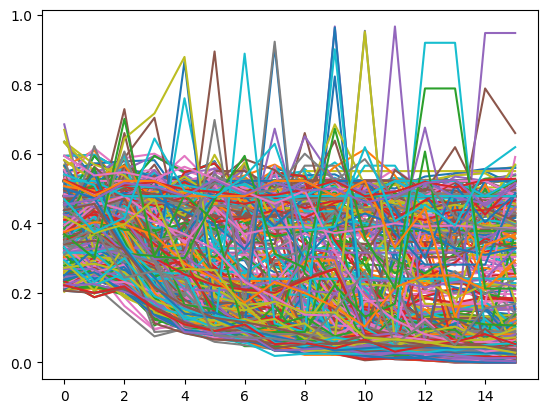

In [ ]:
plt.plot(lcs2.T)


In [9]:
# I want to find all the preprocessor columns, that is, columns that start with p:pp:

preprocessor_cols = [c for c in df_1dataset.columns if c.startswith("p:pp")]

df_1dataset[preprocessor_cols].iloc[500:505]

,p:pp@cat_encoder,p:pp@decomposition,p:pp@featuregen,p:pp@featureselector,p:pp@scaler,p:pp@kernel_pca_kernel,p:pp@kernel_pca_n_components,p:pp@poly_degree,p:pp@selectp_percentile,p:pp@std_with_std
500,onehot,ka_nystroem,none,none,none,linear,0.010000,2,1,True
501,ordinal,fastica,none,selectp,minmax,linear,0.010000,2,57,True
502,none,fastica,none,selectp,std,linear,0.010000,2,82,False
503,ordinal,ka_nystroem,poly,none,minmax,linear,0.010000,2,1,True
504,none,kernel_pca,none,none,std,rbf,0.737377,2,1,True
